## JP morgan swing trading strategy

In [1]:
%load_ext autoreload
%autoreload 2
from finlib import market
import quantstats as qs
import pandas as pd
import matplotlib.pyplot as plt


### Buy and hold

In [4]:
param = {
         "script_path": "/home/mica/finProject/finStuff/databases/db_handler.q", 
         "database_path": "/home/mica/finProject/finStuff/databases/db", 
         "start_date": "2018.11.29", 
         "end_date": "2023.11.29", 
         "ticker": "JPM"
         }

# strategy portfolio (MA crossover)
nyse = market.Market(initial_cash=10000, symbols=["JPM"], params=param)

jpm_price = []

nyse.step()
nyse.add_cash("JPM", 10000)
nyse.step()
nyse.buy_all("JPM")

for _ in range(1250): # magic number because I pandas dataframe will just repeat when last price is reached, no exit cond :p
    nyse.step()
    jpm_price.append(nyse.get_current_price("JPM"))

print(nyse.get_value_portfolio())



15860.837201884742


In [ ]:
# maco indicators
def hull_moving_average(prices, period):
    half_length = int(period / 2)
    sqrt_length = int(period ** 0.5)
    wma_half = prices.rolling(window=half_length).apply(lambda x: (x * range(1, half_length + 1)).sum() / (half_length * (half_length + 1) / 2), raw=True)
    wma_full = prices.rolling(window=period).apply(lambda x: (x * range(1, period + 1)).sum() / (period * (period + 1) / 2), raw=True)
    hull = 2 * wma_half - wma_full
    return hull.rolling(window=sqrt_length).mean()


def efficiency_ratio(prices, period):
    delta = prices.diff()
    up = delta.where(delta > 0, 0).rolling(window=period).sum()
    down = -delta.where(delta < 0, 0).rolling(window=period).sum()
    return up / down


# singal proccesor indicators
def exponential_moving_average(prices, period): # im going to trust that this is correct
    return prices.ewm(span=period, adjust=False).mean()


def moving_average_convergence_divergence(prices, fast_period=12, slow_period=26, signal_period=9):
    ema_fast = exponential_moving_average(prices, fast_period)
    ema_slow = exponential_moving_average(prices, slow_period)
    macd_line = ema_fast - ema_slow
    signal_line = exponential_moving_average(macd_line, signal_period)
    return macd_line, signal_line


def ZScore(prices, period):
    mean = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    return (prices - mean) / std


def bollinger_bands(prices, period=20, num_std_dev=2):
    sma = prices.rolling(window=period).mean()
    std = prices.rolling(window=period).std()
    upper_band = sma + num_std_dev * std
    lower_band = sma - num_std_dev * std
    return upper_band, lower_band

#exposure estimator
def kelly_criterion(win_prob, win_loss_ratio):
    return (win_prob * win_loss_ratio - (1 - win_prob)) / win_loss_ratio


#volatility scalar indicators
def average_true_range(prices, period):
    high_low = prices['High'] - prices['Low']
    high_close = (prices['High'] - prices['Close'].shift()).abs()
    low_close = (prices['Low'] - prices['Close'].shift()).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    return true_range.rolling(window=period).mean()


### Algo

In [ ]:
past_wins = []
past_losses = []


def macro_off_switch(spy, HMA, ER, vix):
    if spy > HMA and ER > 0.3:
        return 0
    elif spy < HMA or vix > 30:
        return 1
    else:
        return 0

def signal_proccessor(p):
    EMA = exponential_moving_average(p, 20)
    MACD, signal_line = moving_average_convergence_divergence(p)
    Z = ZScore(p, 20)
    upper_band, lower_band = bollinger_bands(p)
   
    #vibed below
    # Normalized components (0 to 1)
    z_score_prob = 1.0 if Z < -2.0 else (0.5 if Z < 0 else 0.0)
    macd_prob = 1.0 if MACD > signal_line else 0.0
    bb_prob = 1.0 if p < lower_band else 0.0
    
    # Weighting (must sum to 1.0)
    # Z-Score is the "heart" of mean reversion, so we weight it higher
    weights = {'EMA' : 0.1, 'Z': 0.5, 'MACD': 0.2, 'BB': 0.2}
    
    final_prob = (EMA * weights['EMA']) + \
                 (z_score_prob * weights['Z']) + \
                 (macd_prob * weights['MACD']) + \
                 (bb_prob * weights['BB'])
                 
    return final_prob # Outputs 0.0 to 1.0

def risk_adjusted_reward(past_wins, past_losses):
    avg_win = sum(past_wins) / len(past_wins) if past_wins else 0
    avg_loss = sum(past_losses) / len(past_losses) if past_losses else 1  # avoid division by zero
    return avg_win / avg_loss

def exposure_est(SP, RA):
    return kelly_criterion(SP, RA)
    

def volatility_scalar(prices):
    return average_true_range(prices, 200) / average_true_range(prices, 14)


#p = past 200 prices
def jpm_swing_strat(p, spy, vix, past_wins, past_losses):
   
    HMA = hull_moving_average(p, 200)
    ER = efficiency_ratio(p, 200)

    #damn python fucking sucks at equations
    percent_bought = (
        (exposure_est(signal_proccessor(p), risk_adjusted_reward(past_wins, past_losses))
        * (1 - macro_off_switch(spy=spy, HMA=HMA, ER=ER, vix=vix)))
        * volatility_scalar(p)
    )

    return percent_bought


def stategy_driver(price, spy, vix, market):
    cash = market.get_cash("JPM")
    equity = market.get_value_portfolio("JPM")
    percent_bought = jpm_swing_strat(price, spy, vix, past_wins, past_losses)

    change_in_position = percent_bought - (equity / (cash + equity))
    if change_in_position > 0:
        market.buy("JPM", change_in_position * (cash + equity))
    elif change_in_position < 0:
        market.sell("JPM", -change_in_position * (cash + equity))

   

In [ ]:

for i in range(1250):
    if i > 200: # warmup period for indicators
        stategy_driver(nyse.get_current_price("JPM"), nyse.get_current_price("SPY"), nyse.get_current_price("VIX"), nyse)
    


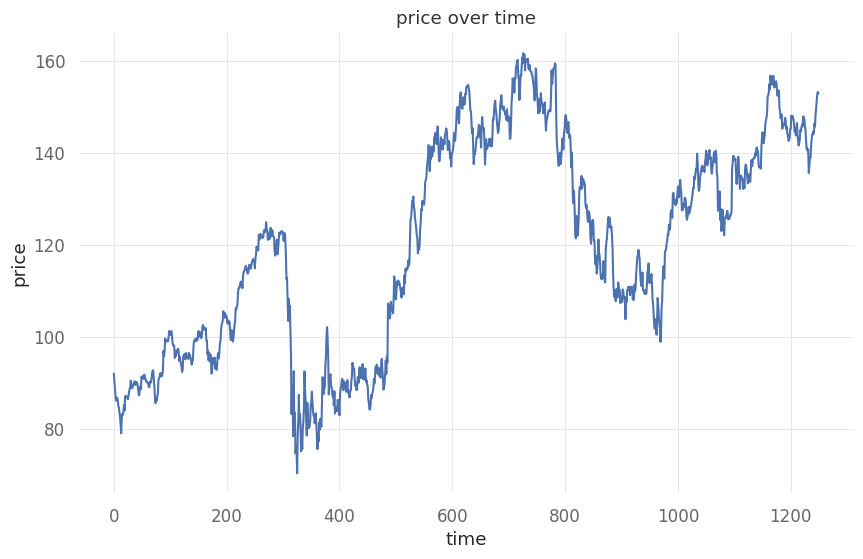

In [3]:
plt.plot(jpm_price)
plt.title("price over time")
plt.xlabel("time")
plt.ylabel("price")
plt.show()